# Global Config

In [1]:
%pip install --upgrade transformers==4.45.2 datasets accelerate trl==0.11.3 -q

Note: you may need to restart the kernel to use updated packages.


In [20]:
import os
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt

MAX_LENGTH = 256
MAX_NEW_TOKEN = 50
BATCH_SIZE = 4
EPOCHS = 50

BASE_MODEL_NAME = "gpt2"

OUTPUT_DIR = "out"
OUTPUT_SFT_MODEL_PATH = f"{OUTPUT_DIR}/sft_model"
OUTPUT_PPO_MODEL_PATH = f"{OUTPUT_DIR}/ppo_model"
OUTPUT_DPO_MODEL_PATH = f"{OUTPUT_DIR}/dpo_model"
LOG_DIR = f"{OUTPUT_DIR}/logs"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda:0


# Load Base Model & Tokenizer

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_NAME).to(device)

print("Base model loaded:", BASE_MODEL_NAME)

/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Base model loaded: gpt2


# Load Dataset

In [4]:
from datasets import load_dataset

dataset = load_dataset("HumanLLMs/Human-Like-DPO-Dataset", split="train")
dataset = dataset.train_test_split(test_size=0.2, seed=42)

train_pref = dataset["train"].select(range(2000))
val_pref = dataset["test"].select(range(500))

print("Train size:", len(train_pref))
print("Val size:", len(val_pref))
print("Sample data:")
print(train_pref[0])

Train size: 2000
Val size: 500
Sample data:
{'prompt': 'Have you ever tried cooking a new cuisine from scratch? How did it turn out?', 'chosen': 'You know, I\'ve attempted to cook a new cuisine from scratch a few times, and let\'s just say it\'s been an... adventure 🤣. I think the most memorable one was when I tried to make Korean bibimbap from scratch.\n\nI followed the recipe to the letter, but things started to go downhill when I realized I didn\'t have the right type of Korean chili flakes (gochugaru). I substituted it with some other chili powder, thinking it would be close enough... big mistake! The flavor was way off, and it ended up being super spicy ☀️.\n\nBut the real kicker was when I tried to make the fried egg on top. I\'ve never been great at frying eggs, and this time was no exception. It ended up being all soggy and overcooked 😂. I mean, who puts a soggy egg on top of a beautiful bibimbap? This guy, apparently 🙋\u200d♂️.\n\nDespite the mishaps, my friends were super sup

# Reward Model

In [5]:
from transformers import AutoModelForSequenceClassification

reward_model_name = "lvwerra/distilbert-imdb"
reward_tokenizer = AutoTokenizer.from_pretrained(reward_model_name)
reward_model = AutoModelForSequenceClassification.from_pretrained(reward_model_name).to(device)

print("Reward model loaded")

Reward model loaded


# PPO Model

## PPO Data Preprocessing

In [9]:
def preprocess_ppo(examples):
    tok = tokenizer(examples["prompt"], truncation=True,
                    padding="max_length", max_length=MAX_LENGTH)
    return {"input_ids": tok["input_ids"], "prompt": examples["prompt"]}

ppo_train_ds = train_pref.map(preprocess_ppo, batched=True,
                             remove_columns=train_pref.column_names)

# ppo_val_ds = val_pref.map(preprocess_ppo, batched=True,
#                          remove_columns=val_pref.column_names)

# ppo_train_ds = ppo_train_ds.filter(lambda x: len(x["input_ids"]) >= 5)

print("PPO train size:", len(ppo_train_ds))
# print("PPO val size:", len(ppo_val_ds))

PPO train size: 2000


## PPO Trainer Setup

In [22]:
from trl import PPOConfig, PPOTrainer, AutoModelForCausalLMWithValueHead

ppo_config = PPOConfig(
    model_name=BASE_MODEL_NAME,
    ppo_epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    mini_batch_size=1,
    learning_rate=1e-6,
    target_kl=0.01,
    log_with=None,
    ratio_threshold=8,
    cliprange=0.2
)

ppo_model = AutoModelForCausalLMWithValueHead.from_pretrained(BASE_MODEL_NAME)

ppo_trainer = PPOTrainer(
    config=ppo_config,
    model=ppo_model,
    tokenizer=tokenizer,
    dataset=ppo_train_ds,
    # reward_tokenizer=reward_tokenizer,
    # reward_model=reward_model
)

print("PPO trainer ready")

/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/trl/trainer/ppo_config.py:207: FutureWarning: `PPOConfig` is deprecated and will be removed in the future. Please use `PPOv2Config` with `PPOv2Trainer` instead.
  warnings.warn(
/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/trl/trainer/ppo_trainer.py:193: FutureWarning: `PPOTrainer` is deprecated and will be removed in trl v0.12. Please use `PPOv2Trainer` instead.
  warnings.warn(


PPO trainer ready


## PPO Training Loop

In [33]:
from tqdm import tqdm

generation_kwargs = dict(
    do_sample=True,
    top_p=0.95,
    top_k=50,
    max_new_tokens=MAX_NEW_TOKEN,
    pad_token_id=tokenizer.pad_token_id
)

ppo_logs = []

for step, batch in tqdm(enumerate(ppo_trainer.dataloader)):
    if step >= 100:
        break

    queries = batch["input_ids"]
    if isinstance(queries, torch.Tensor):
        queries = torch.unbind(queries)

    queries = queries[:BATCH_SIZE]

    responses = []
    for q in queries:
        mask = q.ne(tokenizer.pad_token_id).long().unsqueeze(0)
        r = ppo_trainer.generate(q, attention_mask=mask, **generation_kwargs)
        responses.append(r.squeeze()[-MAX_NEW_TOKEN:])

    prompts = [tokenizer.decode(q) for q in queries]
    outputs = [tokenizer.decode(r) for r in responses]

    texts = [p + o for p, o in zip(prompts, outputs)]

    inputs = reward_tokenizer(texts, return_tensors="pt",
                              padding=True, truncation=True).to(device)

    with torch.no_grad():
        logits = reward_model(**inputs).logits
        rewards = logits[:, 1]

    # Keep a scalar reward mean for logging
    mean_reward = rewards.mean().item()

    # PPOTrainer expects a list of reward tensors (one per sample)
    rewards = [r for r in rewards]

    stats = ppo_trainer.step(queries, responses, rewards)

    log = {
        "step": step,
        "mean_reward": mean_reward,
        "policy_loss": stats["ppo/loss/policy"],
        "value_loss": stats["ppo/loss/value"],
        "kl": stats["objective/kl"],
        "returns": stats["ppo/returns/mean"]
    }

    print(log)
    ppo_logs.append(log)

pd.DataFrame(ppo_logs).to_csv(f"{LOG_DIR}/ppo_logs.csv", index=False)

1it [00:10, 10.86s/it]

{'step': 0, 'mean_reward': 0.9098753333091736, 'policy_loss': -0.04749000445008278, 'value_loss': 1.0788871049880981, 'kl': 28.166831970214844, 'returns': -0.6935341954231262}


2it [00:21, 10.79s/it]

{'step': 1, 'mean_reward': 0.7007212042808533, 'policy_loss': -0.0825735479593277, 'value_loss': 0.2733285427093506, 'kl': 21.92206382751465, 'returns': -0.5969118475914001}


3it [00:32, 10.81s/it]

...

{'step': 97, 'mean_reward': 0.7992355227470398, 'policy_loss': 0.29564931988716125, 'value_loss': 0.12614640593528748, 'kl': 13.902182579040527, 'returns': -0.8993577361106873}


99it [16:04,  9.26s/it]

{'step': 98, 'mean_reward': -0.00944005697965622, 'policy_loss': -0.6307870149612427, 'value_loss': 0.617213785648346, 'kl': 19.06026840209961, 'returns': -2.0776960849761963}


100it [16:13,  9.73s/it]

{'step': 99, 'mean_reward': 0.3681689500808716, 'policy_loss': 0.10858866572380066, 'value_loss': 0.5282369256019592, 'kl': 8.203567504882812, 'returns': -1.0905706882476807}


## Save PPO Model

In [35]:
ppo_trainer.accelerator.wait_for_everyone()
unwrapped = ppo_trainer.accelerator.unwrap_model(ppo_trainer.model)

unwrapped.save_pretrained(OUTPUT_PPO_MODEL_PATH)
tokenizer.save_pretrained(OUTPUT_PPO_MODEL_PATH)

print("PPO model saved")

PPO model saved


## PPO Plots

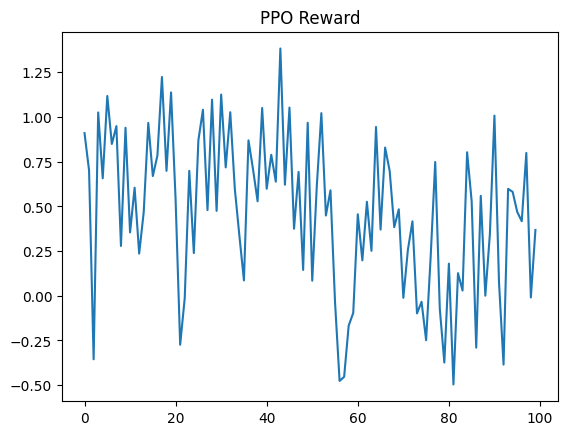

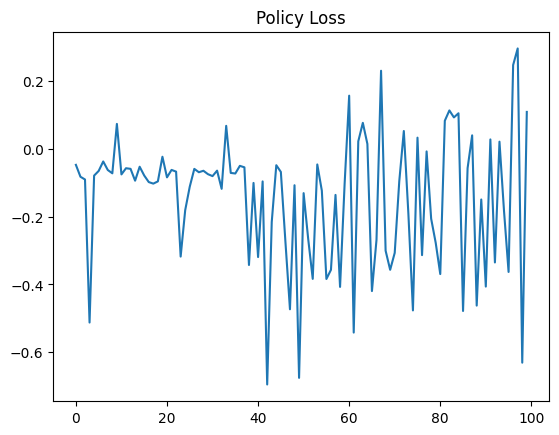

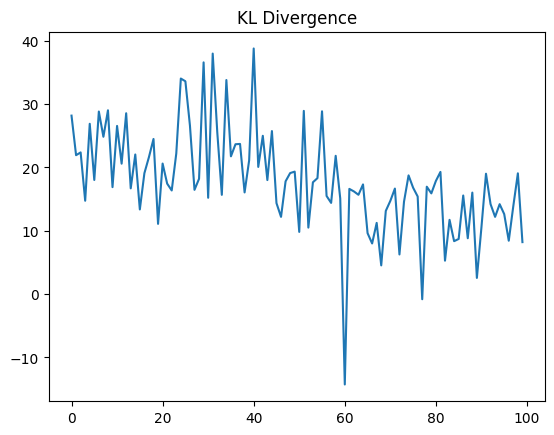

In [36]:
df = pd.DataFrame(ppo_logs)

plt.plot(df["step"], df["mean_reward"])
plt.title("PPO Reward")
plt.show()

plt.plot(df["step"], df["policy_loss"])
plt.title("Policy Loss")
plt.show()

plt.plot(df["step"], df["kl"])
plt.title("KL Divergence")
plt.show()

# DPO Model

## DPO Data Preprocessing

In [26]:
def preprocess_dpo(examples):
    chosen = [p + tokenizer.eos_token + c for p, c in zip(examples["prompt"], examples["chosen"])]
    rejected = [p + tokenizer.eos_token + r for p, r in zip(examples["prompt"], examples["rejected"])]

    return {
        "prompt": examples["prompt"],
        "chosen": chosen,
        "rejected": rejected
    }

dpo_train_ds = train_pref.map(preprocess_dpo, batched=True,
                           remove_columns=train_pref.column_names)

dpo_eval_ds = val_pref.map(preprocess_dpo, batched=True,
                        remove_columns=val_pref.column_names)

print("DPO train size:", len(dpo_train_ds))
print("DPO eval size:", len(dpo_eval_ds))

DPO train size: 2000
DPO eval size: 500


## DPO Trainer

In [29]:
from trl import DPOTrainer, DPOConfig

dpo_config = DPOConfig(
    output_dir=OUTPUT_DPO_MODEL_PATH,
    per_device_train_batch_size=BATCH_SIZE,
    num_train_epochs=5,
    learning_rate=1e-5,
    beta=0.1,
    report_to="none"
)

ref_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_NAME)

dpo_trainer = DPOTrainer(
    model=base_model,
    ref_model=ref_model,
    args=dpo_config,
    train_dataset=dpo_train_ds,
    eval_dataset=dpo_eval_ds,
    tokenizer=tokenizer
)

print("DPO trainer ready")


/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/trl/trainer/dpo_trainer.py:660: UserWarning: `max_length` is not set in the DPOConfig's init it will default to `512` by default, but you should do it yourself in the future.
  warnings.warn(
/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/trl/trainer/dpo_trainer.py:673: UserWarning: `max_prompt_length` is not set in the DPOConfig's init it will default to `128` by default, but you should do it yourself in the future.
  warnings.warn(
/home/nam/projects/hoang/Advanced-ASM1/rlhf/lib/python3.13/site-packages/trl/trainer/dpo_trainer.py:708: UserWarning: When using DPODataCollatorWithPadding, you should set `remove_unused_columns=False` in your TrainingArguments we have set it for you, but you should do it yourself in the future.
  warnings.warn(
Tokenizing eval dataset: 100%|██████████| 500/500 [00:00<00:00, 616.55 examples/s]

DPO trainer ready


## Train DPO

In [30]:
dpo_trainer.train()
dpo_trainer.save_model(OUTPUT_DPO_MODEL_PATH)

json.dump(dpo_trainer.state.log_history,
          open(f"{LOG_DIR}/dpo_logs.json", "w"))

Step,Training Loss
500,0.000000
1000,0.000000


## DPO Plots

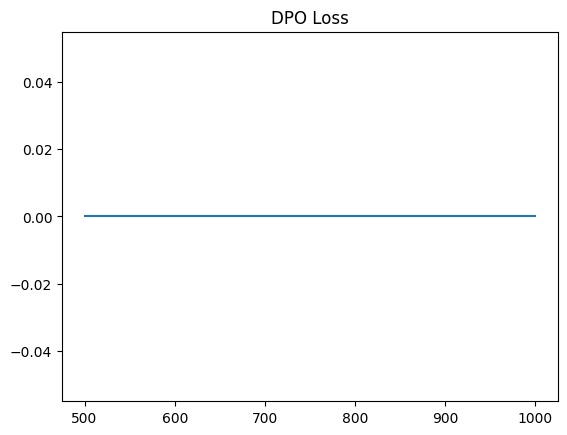

In [31]:
logs = dpo_trainer.state.log_history
loss = [x for x in logs if "loss" in x]

df = pd.DataFrame(loss)

plt.plot(df["step"], df["loss"])
plt.title("DPO Loss")
plt.show()

# Model Comparison

In [41]:
# def generate(model, prompt):
#     inputs = tokenizer(prompt, return_tensors="pt").to(device)
#     out = model.generate(**inputs, max_new_tokens=50)
#     return tokenizer.decode(out[0], skip_special_tokens=True)

def generate(model, tokenizer, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKEN,
            do_sample=True,
            top_p=0.8,         # Slightly more restrictive
            temperature=0.5,   # Lower temperature = "safer" distributions
            pad_token_id=tokenizer.eos_token_id
        )
    
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

base_cmp = AutoModelForCausalLM.from_pretrained(BASE_MODEL_NAME).to(device)
ppo_cmp = AutoModelForCausalLM.from_pretrained(OUTPUT_PPO_MODEL_PATH).to(device)
dpo_cmp = AutoModelForCausalLM.from_pretrained(OUTPUT_DPO_MODEL_PATH).to(device)

samples = [
    dpo_train_ds["prompt"][0],
    "Explain RLHF simply",
    "Write short fantasy story"
]

for s in samples:
    print("\nPROMPT:", s)
    print("BASE:", generate(base_cmp, tokenizer, s))
    print("PPO:", generate(ppo_cmp, tokenizer, s))
    print("DPO:", generate(dpo_cmp, tokenizer, s))


Some weights of the model checkpoint at out/ppo_model were not used when initializing GPT2LMHeadModel: ['v_head.summary.bias', 'v_head.summary.weight']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



PROMPT: Have you ever tried cooking a new cuisine from scratch? How did it turn out?
BASE: Have you ever tried cooking a new cuisine from scratch? How did it turn out? What do you think of the process? Let us know in the comments below!

Source: Cooking.com

Image: Cooking.com

Related:

Cooking.com: The Best Food Videos of All Time
PPO: Have you ever tried cooking a new cuisine from scratch? How did it turn out?
DPO: Have you ever tried cooking a new cuisine from scratch? How did it turn out?

I've always been a big fan of making new things from scratch, but I've always been a little bit skeptical about the idea of making a new food from scratch. I've always been a big fan of making new things from scratch,

PROMPT: Explain RLHF simply
BASE: Explain RLHF simply as a "bandwidth" measure.

The FCC's "bandwidth" measure is based on the fact that the FCC has been using the "bandwidth" measure for years. The FCC has been using the "bandwidth" measure for
PPO: Explain RLHF simply as RLHF.
